lin mse:  524.9715634325903
lin r2:  0.7993839291669449

cubic mse:  131.19324309888745
cubic r2:  0.94986495501156
cubic better fit


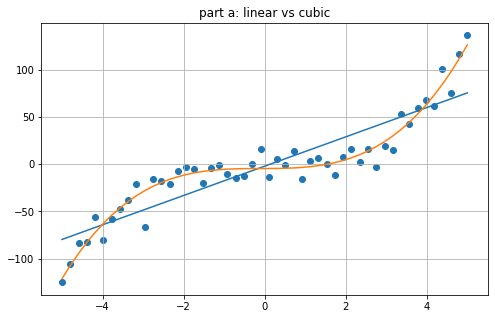

degree:  1
mse:  524.9715634325903
r2:  0.7993839291669449


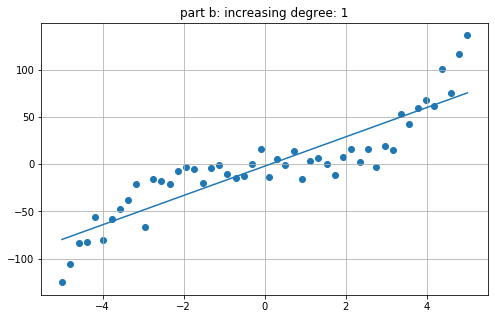

degree:  2
mse:  519.9996571582268
r2:  0.8012839259873272


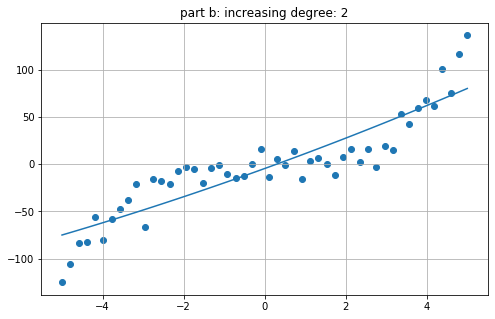

degree:  3
mse:  131.19324309888745
r2:  0.94986495501156


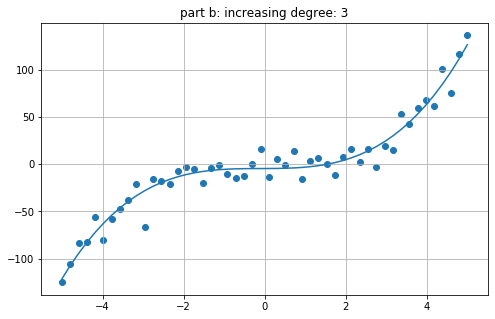

degree:  4
mse:  127.5502531269059
r2:  0.951257111054231


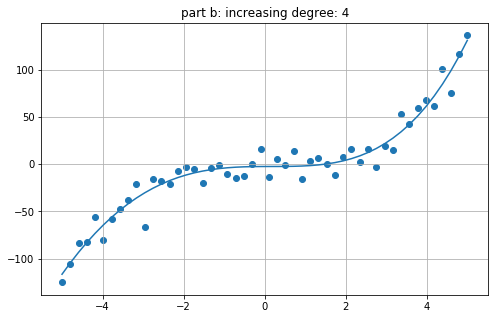

degree:  5
mse:  127.15188936573226
r2:  0.9514093443904643


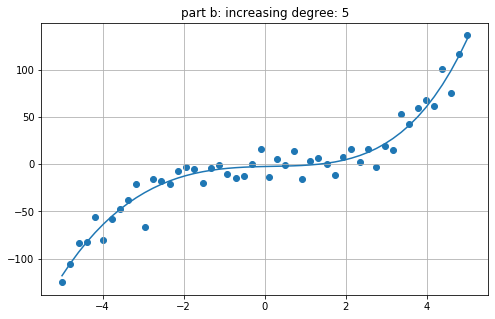

degree:  6
mse:  126.0117378161233
r2:  0.9518450493694943


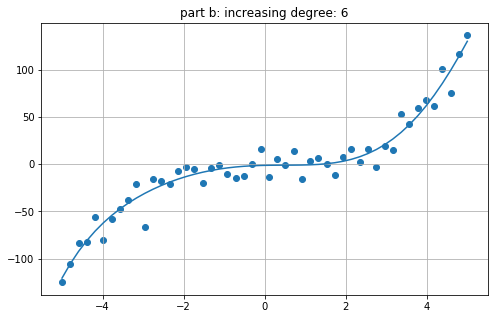

degree:  7
mse:  125.6637796108869
r2:  0.9519780203965195


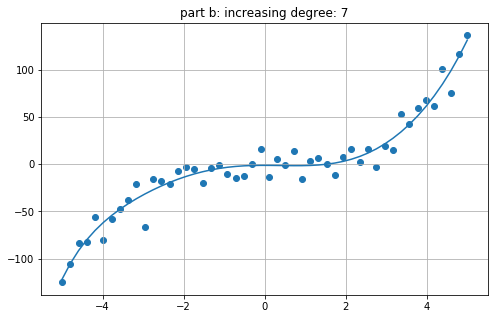

degree:  8
mse:  125.6600767430802
r2:  0.95197943543467


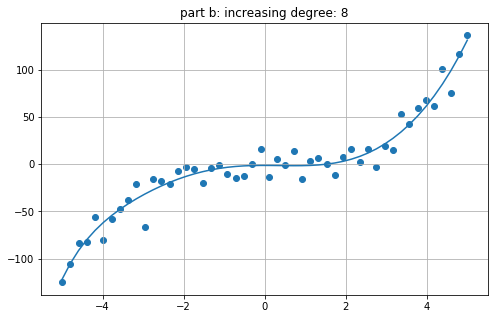

degree:  9
mse:  115.46552678261354
r2:  0.9558752475118183


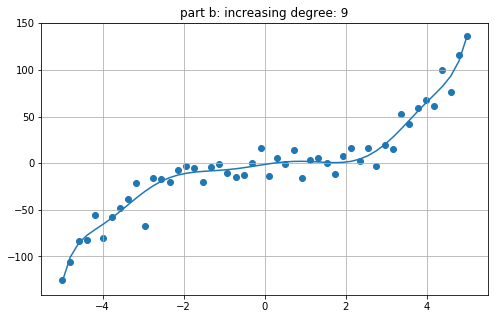

degree:  10
mse:  114.7448076347555
r2:  0.9561506678463446


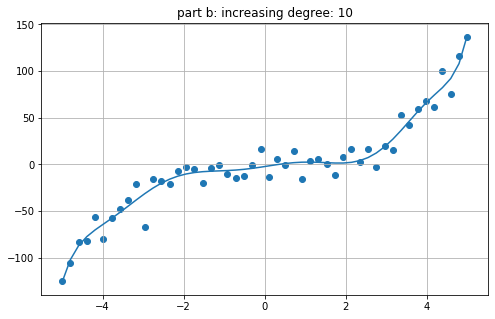

degree:  11
mse:  114.6940582614213
r2:  0.9561700615441842


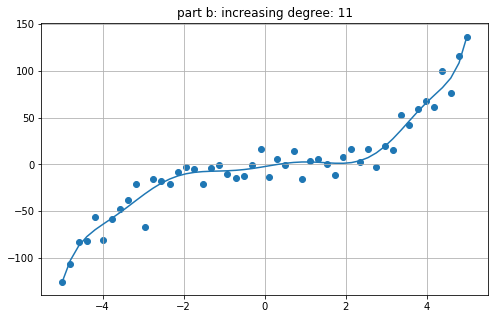

degree:  12
mse:  114.52373543854834
r2:  0.9562351498230132


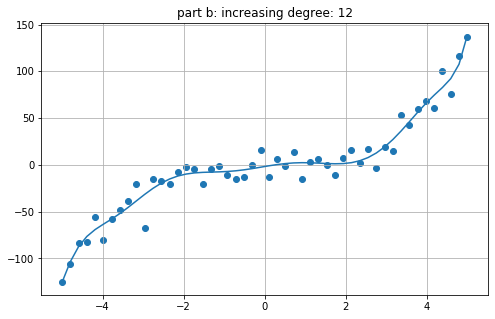

degree:  13
mse:  114.45625923725231
r2:  0.9562609356204195


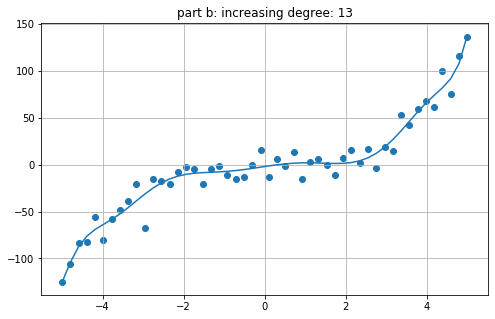

degree:  14
mse:  112.37459640821899
r2:  0.9570564358849085


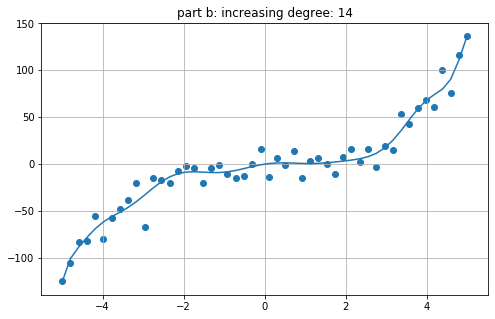

vandermonde mse:  131.1932430988874
vandermonde r2:  0.94986495501156


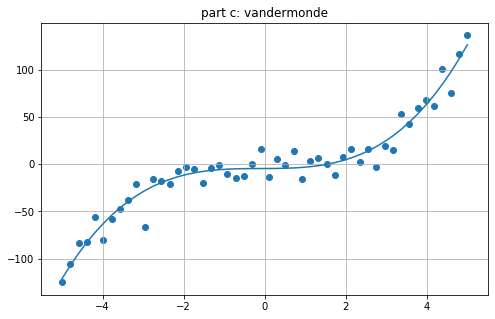

In [21]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(None)

x = np.linspace(-5, 5, 50)
y = x**3 + np.random.normal(0,10,len(x))

def mse(y_true, y_pred):
    
    total = 0
    
    for i in range(len(y_true)):
        total += (y_true[i] - y_pred[i])**2
        
    return total/len(y_true)

def r2(y_true, y_pred):
    mean_y = np.mean(y_true)
    
    ss_res = 0
    ss_tot = 0
    
    for i in range(len(y_true)):
        ss_res += (y_true[i] - y_pred[i])**2
        ss_tot += (y_true[i] - mean_y)**2

    return 1 - ss_res/ss_tot

## === A ===

linCoeff = np.polyfit(x,y,1)
y_lin = np.polyval(linCoeff,x)

cubCoeff = np.polyfit(x,y,3)
y_cub = np.polyval(cubCoeff,x)

mseLin = mse(y,y_lin)
mseCub = mse(y,y_cub)

r2Lin = r2(y,y_lin)
r2Cub = r2(y,y_cub)

print("lin mse: ", mseLin)
print("lin r2: ", r2Lin)

print("\ncubic mse: ", mseCub)
print("cubic r2: ", r2Cub)

if r2Cub > r2Lin:
    print("cubic better fit")
else:
    print("linear better fit")
    
plt.figure(figsize=(8,5))
plt.scatter(x,y)
plt.plot(x,y_lin)
plt.plot(x,y_cub)
plt.grid()
plt.title("part a: linear vs cubic")
plt.show()

## === B ===

for deg in range(1,15):
    coeff = np.polyfit(x,y,deg)
    y_pred = np.polyval(coeff,x)
    
    error = mse(y,y_pred)
    rsq = r2(y,y_pred)
    
    print("degree: ", deg)
    print("mse: ", error)
    print("r2: ", rsq)
    
    plt.figure(figsize=(8,5))
    plt.scatter(x,y)
    plt.plot(x,y_pred)
    plt.grid()
    plt.title(f"part b: increasing degree: {deg}")
    plt.show()
    
## === C ===

deg = 3

v = np.vander(x,deg+1)
vanCoeff = np.linalg.lstsq(v,y,rcond=None)[0]
y_van = v @ vanCoeff

mse_van = mse(y,y_van)
r2_van = r2(y,y_van)

print("vandermonde mse: ", mse_van)
print("vandermonde r2: ", r2_van)

plt.figure(figsize=(8,5))
plt.scatter(x,y)
plt.plot(x,y_van)
plt.grid()
plt.title("part c: vandermonde")
plt.show()